In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [30]:
data_loc = './Ali'

data = pd.read_csv(data_loc + '/use_train_A.csv')
# data = data[data['ts'] >= '2020-01-01']
# data = data[data['ts'] <= '2020-12-31']

In [31]:
len(data['product'].unique())

19

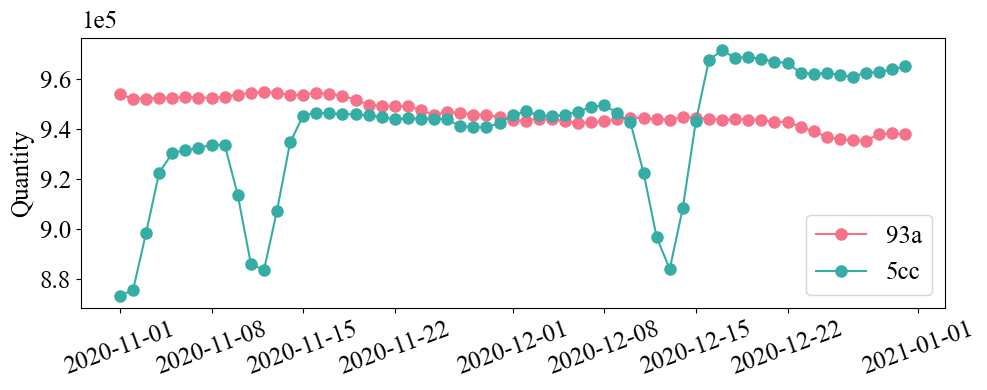

In [32]:
# 将同一个product_id的数据合并
# data = data.groupby(['product', 'ts']).agg({'qty': 'sum'}).reset_index()
plt.rc('font', family='Times New Roman')
colors = sns.color_palette("Set2", 2)
colors = sns.color_palette("husl",2)
plt.figure(figsize=(10,4))
data['ts'] = pd.to_datetime(data['ts'])
data = data[(data['ts'] >= '2020-11-01') & (data['ts'] <= '2020-12-31')]
# 选择qty最大的三个product
data_tmp = data.groupby('product').agg({'qty': 'sum'}).reset_index()
data_tmp = data_tmp.sort_values('qty', ascending=False)
prod_id = data_tmp['product'][:].values
for p in prod_id[:]:
    if p.startswith('93a') or p.startswith('5cc'):
        data_p = data[data['product'] == p]
        data_p = data_p.groupby('ts').agg({'qty': 'sum'}).reset_index()
        data_p = data_p.sort_values('ts')
        plt.plot(data_p['ts'], data_p['qty'], label=p[:3], linestyle='-', marker='o', markersize=8, color=colors[prod_id.tolist().index(p)])


# plt.title("Demand of Cloud Service Products (2020/11/01-2020/12/31, TOP 2)")

# plt.xlabel('ts', fontsize=15)
plt.ylabel('qty', fontsize=18)
plt.xticks(rotation=20, fontsize=18)
plt.yticks(fontsize=18)
# y轴使用科学计数法
# plt.gca().get_yaxis().set_major_formatter(plt.ScalarFormatter())
# plt.xlabel("Date")
plt.ylabel("Quantity")
# plt.grid(axis='both')
plt.legend(fontsize = 18)
#添加这部分代码
ax = plt.gca()
ax.ticklabel_format(style='sci', scilimits=(-1,2), axis='y')
ax.get_yaxis().get_offset_text().set(va='bottom', ha='left')
ax.yaxis.get_offset_text().set_fontsize(18)#设置1e6的大小与位置

plt.tight_layout()
plt.show()

In [51]:
data_tmp = data_tmp.iloc[:4, :]

93a97f63f0a573483d49c58dc02c1341 2019-12-31 2021-03-01
5cc8015f03554313900f069182bdaf9c 2018-06-04 2021-03-01
6c46c9c5d3ef936b4c8d6d8f9851e837 2019-12-31 2021-03-01


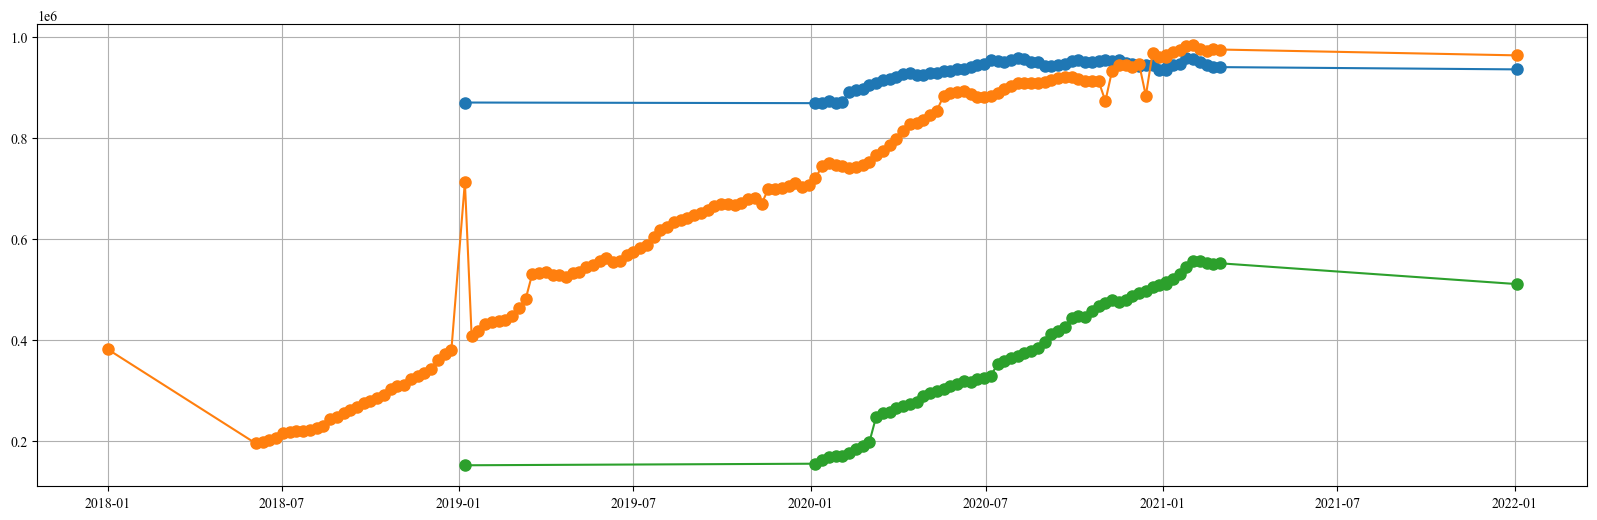

In [54]:
data = pd.read_csv(data_loc + '/use_train_A.csv')
plt.figure(figsize=(20,6))
for PRODUCT_ID in data_tmp['product'].unique():
    data_prod = data[data['product'] == PRODUCT_ID]
    print(PRODUCT_ID, data_prod['ts'].min(), data_prod['ts'].max())
    data_prod = data_prod.groupby('ts').agg({'qty': 'sum'}).reset_index()


    data_prod['ts'] = pd.to_datetime(data_prod['ts'])
    data_prod['year'] = data_prod['ts'].dt.year
    data_prod['week'] = data_prod['ts'].dt.isocalendar().week
    # 新增一个year_week字段，用于绘制折线图，格式为year-week，如果week为个位数，前面补0
    data_prod['year_week'] = data_prod['year'].astype(str) + '-' + data_prod['week'].apply(lambda x: '0'+str(x) if x<10 else str(x))
    data_prod = data_prod.groupby(['year_week']).agg({'qty': 'last'}).reset_index()

    data_prod['year_week'] = pd.to_datetime(data_prod['year_week'] + '-1', format='%Y-%W-%w')  # 将year-week转换为日期格式
    data_prod = data_prod.sort_values('year_week')
    plt.plot(data_prod['year_week'], data_prod['qty'], label=PRODUCT_ID, linestyle='-', marker='o', markersize=8)

plt.grid()
plt.show()

In [61]:
for PRODUCT_ID in data_tmp['product'].unique():
    arrival_rate = data[data['product'] == PRODUCT_ID]['qty'].mean()
    arrival_rate_std = data[data['product'] == PRODUCT_ID]['qty'].std()
    print(PRODUCT_ID, arrival_rate - arrival_rate_std*0.2, arrival_rate, arrival_rate + arrival_rate_std*0.2)

93a97f63f0a573483d49c58dc02c1341 23314.371255924103 30843.181804115735 38371.99235230737
5cc8015f03554313900f069182bdaf9c 13123.514545896687 16011.99856021013 18900.482574523572
6c46c9c5d3ef936b4c8d6d8f9851e837 6661.538860774946 9894.310083364751 13127.081305954556
